5099 65535


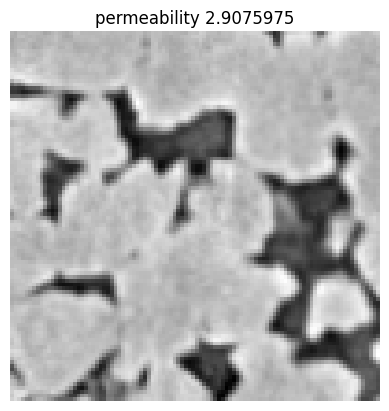

In [1]:
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path
from drp.utils.config import Config
from drp.data.dataset import Drp3dSqlite

root_path = Path("/work/lecomtje/Repositories/mixsim3d_gretsi/tests")
config: Config = Config(root_path / "config.json")

def unormalize(value):
    return int(value.item()*config.std + config.mean)

dataset = Drp3dSqlite(config, train_flag="train")
idx = 3456
cube, y, cube_id = dataset[idx]
print(unormalize(torch.min(cube)), unormalize(torch.max(cube)))

plt.imshow(cube[0, :, : , 50], cmap='gray')
plt.title(f"permeability {y}")
_ = plt.axis('off') 


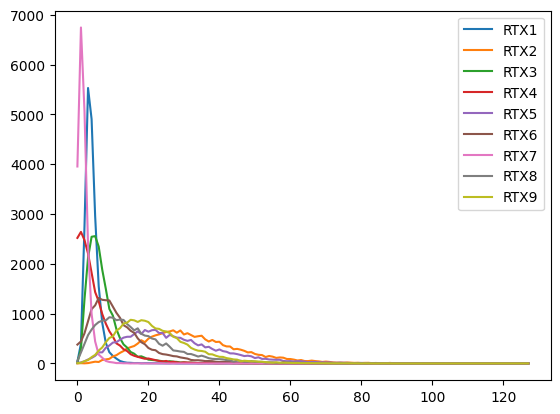

In [12]:
import pandas as pd
import numpy as np
from drp.data.sqlite_dataset import SqliteDataset


perm_by_groups = {}
with SqliteDataset(db_path=config.db) as db:
    # Récupérer les données
    query = """
    SELECT
    RTX,
    GROUP_CONCAT(permeability, ', ') AS permeabilities
    FROM
    dataset
    GROUP BY
    RTX;
    """
    cursor = db.conn.cursor()
    cursor.execute(query)
    for table in  cursor.fetchall():
        values = table[1].split(',')
        perm_by_groups[table[0]] = np.array(values, dtype=float)


for k, v in perm_by_groups.items():
    hist, bins = np.histogram(v, 128)
    plt.plot(hist, label=k)
plt.legend(loc="upper right")   


In [2]:
permeabilities = {
    4419: [],
    4420: []
}
for item in tqdm(dataset):
    _, perm, cube_id = item
    permeabilities[cube_id].append(perm)


100%|██████████| 4806/4806 [00:18<00:00, 265.72it/s]


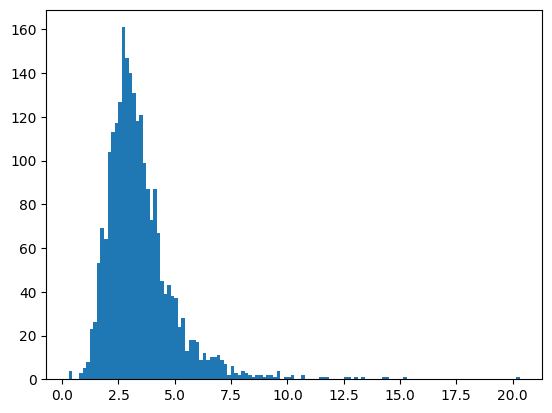

In [3]:
hist = plt.hist(permeabilities[4419], bins=128)

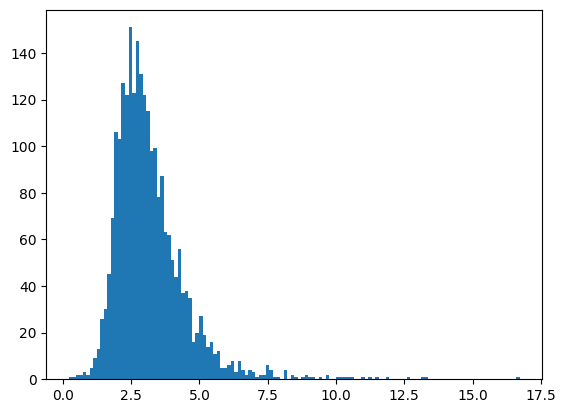

In [8]:
hist = plt.hist(permeabilities[4420], bins=128)